In [1]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('Retail_dataset.csv', encoding='latin1')

In [2]:
print(df.head())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (541909, 8)


In [4]:
print(df.dtypes)

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [5]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical features:", numerical_features)

Numerical features: ['Quantity', 'UnitPrice', 'CustomerID']


In [6]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_features)


Categorical features: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


C:\Users\USER\AppData\Local\Temp\ipykernel_4336\1611694888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [7]:
print(df.nunique())


InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


In [8]:
possible_keys = [col for col in df.columns if df[col].nunique() == len(df)]
print("Single-column possible primary keys:", possible_keys)

Single-column possible primary keys: []


In [9]:
composite_duplicates = df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()
print("Duplicate (InvoiceNo, StockCode) rows:", composite_duplicates)


Duplicate (InvoiceNo, StockCode) rows: 10684


In [10]:
print(df.isnull().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())


Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [12]:
print(df['Country'].value_counts().head(10))


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


In [13]:
uk_share = (df['Country'] == 'United Kingdom').sum() / len(df) * 100
print("UK % of rows:", uk_share)

UK % of rows: 91.43195628786383


In [14]:
negative_qty_count = (df['Quantity'] < 0).sum()
print("Negative quantity rows (likely returns):", negative_qty_count)

Negative quantity rows (likely returns): 10624


This dataset contains 541,909 transactional records from an online retail store, spanning December 1, 2010 to December 9, 2011. Each row represents one product purchased within a specific customer invoice, including product details, quantity, price, purchase date, and customer/country information.

This dataset contains **transactional records from an online retail store**, covering **541,909 rows** and **8 columns**. Each row represents a single line item within a customer's order (i.e., one product purchased in one invoice).

**Key details:**
- **Time period:** December 1, 2010 to December 9, 2011 (about a year)
- **Invoices:** 25,900 unique orders
- **Products:** 4,070 unique items (identified by `StockCode`, described in `Description`)
- **Customers:** 4,372 unique customers (`CustomerID`)
- **Countries:** 38 countries, dominated by the **United Kingdom** (495,478 rows / ~91.43%), followed by Germany (9,495), France (8,557), EIRE (8,196), and Spain (2,533)
- **Missing data:** `Description` has 1,454 missing values; `CustomerID` has 135,080 missing values (likely guest/unregistered purchases)
- **Returns:** 10,624 rows have negative `Quantity`, likely representing returns or order cancellations

**Columns:**

| Column | Meaning |
|---|---|
| InvoiceNo | Order/invoice number |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units purchased (can be negative — likely returns) |
| InvoiceDate | Date/time of the transaction |
| UnitPrice | Price per unit |
| CustomerID | Customer identifier |
| Country | Customer's country |

**Primary key note:** No single column uniquely identifies each row; the composite key **(InvoiceNo, StockCode)** together identifies each line item.

In short: it's a real-world **e-commerce sales log**, well-suited for analyses like customer segmentation (RFM analysis), sales trends over time, top-selling products, geographic sales patterns, and return/refund behavior.

In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv('Retail_dataset.csv', encoding='latin1')
print("Original shape:", df.shape)

Original shape: (541909, 8)


In [16]:
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

Missing values per column:
Description      1454
CustomerID     135080
dtype: int64


In [17]:
df['Description'] = df.groupby('StockCode')['Description'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)


In [18]:
df['Description'] = df['Description'].fillna('Unknown')

In [19]:
df['CustomerID'] = df['CustomerID'].fillna(-1)

In [20]:
print("Missing values after handling:")

Missing values after handling:


In [21]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [22]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows found:", duplicate_count)

Number of duplicate rows found: 5268


In [23]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicates removed:", duplicate_count)

Shape after removing duplicates: (536641, 8)
Duplicates removed: 5268


In [24]:
df.columns = df.columns.str.strip().str.lower()

In [25]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], format='%m/%d/%Y %H:%M')

In [26]:
df['description'] = df['description'].str.strip().str.upper()
df['country'] = df['country'].str.strip().str.title()

In [27]:
df['customerid'] = df['customerid'].astype(int)  # now safe since no missing values remain
df['invoiceno'] = df['invoiceno'].astype(str)
df['stockcode'] = df['stockcode'].astype(str)

In [28]:
print(df.dtypes)


invoiceno                 str
stockcode                 str
description               str
quantity                int64
invoicedate    datetime64[us]
unitprice             float64
customerid              int64
country                   str
dtype: object


In [29]:
invalid_price = df[df['unitprice'] <= 0]
print("Rows with invalid UnitPrice (<=0):", len(invalid_price))
df = df[df['unitprice'] > 0]

Rows with invalid UnitPrice (<=0): 2512


In [30]:
cancelled_orders = df[df['invoiceno'].str.startswith('C')]
print("Cancelled order rows (InvoiceNo starts with 'C'):", len(cancelled_orders))

Cancelled order rows (InvoiceNo starts with 'C'): 9251


In [31]:
df['is_cancelled'] = df['invoiceno'].str.startswith('C')


In [32]:
anomalous_qty = df[(df['quantity'] < 0) & (~df['is_cancelled'])]
print("Negative Quantity rows NOT linked to a cancellation (anomalies):", len(anomalous_qty))

Negative Quantity rows NOT linked to a cancellation (anomalies): 0


In [33]:
print("Final cleaned shape:", df.shape)

Final cleaned shape: (534129, 9)


In [34]:
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (Description)',
        'Missing Values (CustomerID)',
        'Duplicates',
        'Invalid Entries (UnitPrice <= 0)',
        'Standardization (dates/text/columns/dtypes)'
    ],
    'Action Taken': [
        'Filled 1,454 missing values using the most common Description per StockCode',
        'Filled 135,080 missing values with -1 flag (guest/unregistered purchase)',
        'Removed 5,268 duplicate rows',
        'Removed 2,512 rows with UnitPrice <= 0',
        'Applied — lowercase column names, InvoiceDate converted to datetime, Description upper-case, Country title-case, correct dtypes for CustomerID/InvoiceNo/StockCode'
    ]
})

In [35]:
print(cleaning_summary)

                                   Issue Found  \
0                 Missing Values (Description)   
1                  Missing Values (CustomerID)   
2                                   Duplicates   
3             Invalid Entries (UnitPrice <= 0)   
4  Standardization (dates/text/columns/dtypes)   

                                        Action Taken  
0  Filled 1,454 missing values using the most com...  
1  Filled 135,080 missing values with -1 flag (gu...  
2                       Removed 5,268 duplicate rows  
3             Removed 2,512 rows with UnitPrice <= 0  
4  Applied — lowercase column names, InvoiceDate ...  


## 2. Data Cleaning Process

Perform the following cleaning steps and document every action taken.

**Missing Values**
- `Description`: 1,454 missing values filled using the most common Description per matching `StockCode`.
- `CustomerID`: 135,080 missing values filled with -1 to flag guest/unregistered purchases (cannot be reliably imputed since it's a unique identifier).

**Duplicate Records**
- 5,268 duplicate rows identified and removed.

**Standardization**
- Column names converted to lowercase.
- `InvoiceDate` converted from text to proper datetime format.
- `Description` standardized to upper-case; `Country` standardized to title-case.
- Data types corrected (`CustomerID`, `InvoiceNo`, `StockCode`).

**Data Validation**
- 2,512 rows with `UnitPrice` <= 0 identified as invalid and removed.
- 9,251 cancelled orders (`InvoiceNo` starting with "C") flagged with a new `is_cancelled` column rather than deleted.
- All 10,624 negative-`Quantity` rows were checked against cancellations — all matched genuine cancellations, so none were removed as anomalies.

**Cleaning Summary**

| Issue Found | Action Taken |
|---|---|
| Missing Values (Description) | Filled 1,454 missing values using the most common Description per StockCode |
| Missing Values (CustomerID) | Filled 135,080 missing values with -1 flag (guest/unregistered purchase) |
| Duplicates | Removed 5,268 duplicate rows |
| Invalid Entries (UnitPrice <= 0) | Removed 2,512 rows |
| Standardization | Applied — lowercase columns, datetime InvoiceDate, upper/title case text, correct dtypes |

**Final cleaned shape:** (534,129 rows, 9 columns)

In [36]:
summary_stats = df[['quantity', 'unitprice']].agg(['mean', 'median', 'min', 'max', 'std'])
print("Summary Statistics:")

Summary Statistics:


In [37]:
print(summary_stats)

            quantity     unitprice
mean        9.916818      4.695864
median      3.000000      2.100000
min    -80995.000000      0.001000
max     80995.000000  38970.000000
std       216.452113     95.079189


In [38]:
df['totalprice'] = df['quantity'] * df['unitprice']

In [39]:
totalprice_stats = df['totalprice'].agg(['mean', 'median', 'min', 'max', 'std'])
print("\nTotalPrice Statistics:")
print(totalprice_stats)


TotalPrice Statistics:
mean          18.250518
median         9.900000
min      -168469.600000
max       168469.600000
std          380.945385
Name: totalprice, dtype: float64


In [40]:
print("\nTop Countries by Transaction Count:")


Top Countries by Transaction Count:


In [41]:
print(df['country'].value_counts().head(10))

country
United Kingdom    487806
Germany             9478
France              8540
Eire                8180
Spain               2527
Netherlands         2367
Belgium             2069
Switzerland         1993
Portugal            1510
Australia           1255
Name: count, dtype: int64


In [42]:
monthly_sales = df.groupby(df['invoicedate'].dt.month)['totalprice'].sum()
print("\nMonthly Sales Trend (Total Revenue):")
print(monthly_sales)


Monthly Sales Trend (Total Revenue):
invoicedate
1      558448.560
2      497026.410
3      682013.980
4      492367.841
5      722094.100
6      689977.230
7      680156.991
8      703510.580
9     1017596.682
10    1069368.230
11    1456145.800
12    1179424.670
Name: totalprice, dtype: float64


In [43]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Best-Selling Products:")
print(top_products)


Top 10 Best-Selling Products:
description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64


In [44]:
print("\nCorrelation Matrix:")
print(df[['quantity', 'unitprice', 'totalprice']].corr())


Correlation Matrix:
            quantity  unitprice  totalprice
quantity    1.000000  -0.001376    0.901150
unitprice  -0.001376   1.000000   -0.179055
totalprice  0.901150  -0.179055    1.000000


In [45]:
top_selling_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print("Top-Selling Products (by Quantity):")
print(top_selling_products)


Top-Selling Products (by Quantity):
description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: quantity, dtype: int64


In [46]:
revenue_by_country = df.groupby('country')['totalprice'].sum().sort_values(ascending=False).head(10)
print("\nHighest Revenue-Generating Countries:")
print(revenue_by_country)


Highest Revenue-Generating Countries:
country
United Kingdom    8189252.304
Netherlands        284661.540
Eire               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: totalprice, dtype: float64


In [47]:
monthly_sales = df.groupby(df['invoicedate'].dt.to_period('M'))['totalprice'].sum()
print("\nMonthly Sales Trends:")
print(monthly_sales)


Monthly Sales Trends:
invoicedate
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: totalprice, dtype: float64


In [48]:
most_purchased_products = df.groupby('description')['invoiceno'].nunique().sort_values(ascending=False).head(10)
print("\nMost Purchased Products (by Number of Orders):")
print(most_purchased_products)



Most Purchased Products (by Number of Orders):
description
WHITE HANGING HEART T-LIGHT HOLDER    2298
REGENCY CAKESTAND 3 TIER              2168
JUMBO BAG RED RETROSPOT               2132
PARTY BUNTING                         1705
LUNCH BAG RED RETROSPOT               1607
ASSORTED COLOUR BIRD ORNAMENT         1467
SET OF 3 CAKE TINS PANTRY DESIGN      1458
PACK OF 72 RETROSPOT CAKE CASES       1334
LUNCH BAG  BLACK SKULL.               1295
NATURAL SLATE HEART CHALKBOARD        1266
Name: invoiceno, dtype: int64


In [49]:
top_customers = df[df['customerid'] != -1].groupby('customerid')['totalprice'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customers by Total Spend:")
print(top_customers)


Top 10 Customers by Total Spend:
customerid
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: totalprice, dtype: float64


In [50]:
avg_order_value = df.groupby('invoiceno')['totalprice'].sum().mean()
print("\nAverage Order Value: £{:.2f}".format(avg_order_value))


Average Order Value: £409.65


In [51]:
avg_orders_per_customer = df[df['customerid'] != -1].groupby('customerid')['invoiceno'].nunique().mean()
print("Average Number of Orders per Customer: {:.2f}".format(avg_orders_per_customer))

Average Number of Orders per Customer: 5.08


## 3. Exploratory Data Analysis (EDA)

After cleaning, the following analysis was performed on the numerical columns and key data patterns.

**Summary Statistics**

| Stat | Quantity | UnitPrice | TotalPrice |
|---|---|---|---|
| Mean | 9.92 | 4.70 | 18.25 |
| Median | 3.00 | 2.10 | 9.90 |
| Min | -80,995 | 0.001 | -168,469.60 |
| Max | 80,995 | 38,970.00 | 168,469.60 |
| Std Dev | 216.45 | 95.08 | 380.95 |

**5 Exploratory Analyses**

1. **Top-selling products (by quantity):** "WORLD WAR 2 GLIDERS ASSTD DESIGNS" leads with 53,751 units sold, followed by "JUMBO BAG RED RETROSPOT" (47,256) and "POPCORN HOLDER" (36,322).
2. **Highest revenue-generating countries:** United Kingdom (£8,189,252), followed by Netherlands (£284,662), Eire (£262,993), and Germany (£221,509).
3. **Monthly sales trends:** Revenue rises steadily through the year, peaking in November 2011 (£1,456,146) — consistent with pre-holiday shopping.
4. **Most purchased products (by order frequency):** "WHITE HANGING HEART T-LIGHT HOLDER" (2,298 orders), "REGENCY CAKESTAND 3 TIER" (2,168), "JUMBO BAG RED RETROSPOT" (2,132).
5. **Customer purchasing behavior:** Top customer (ID 14646) spent £279,489; average order value is £409.65; average customer places 5.08 orders.

In [52]:
import matplotlib.pyplot as plt

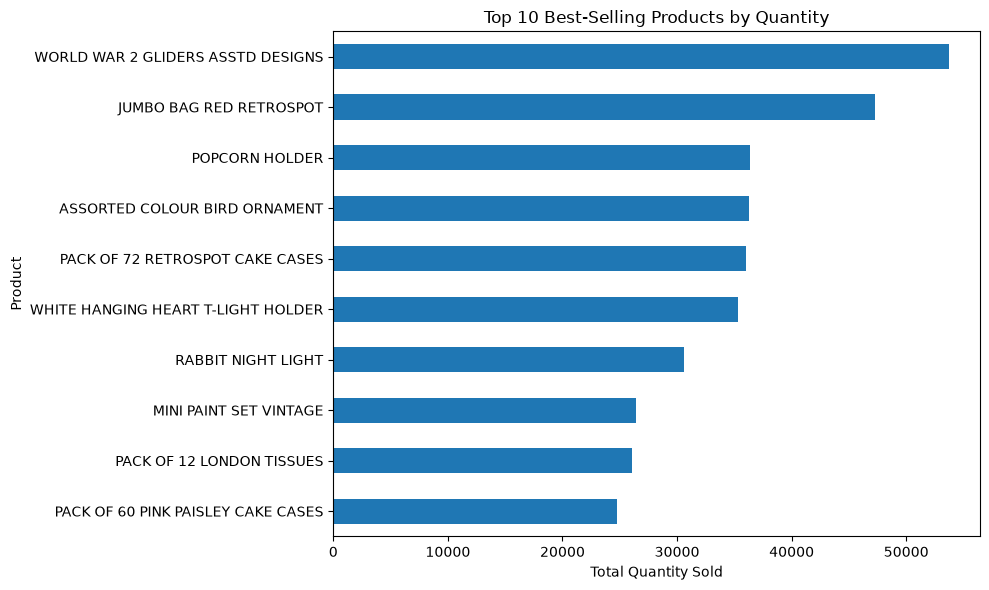

In [53]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

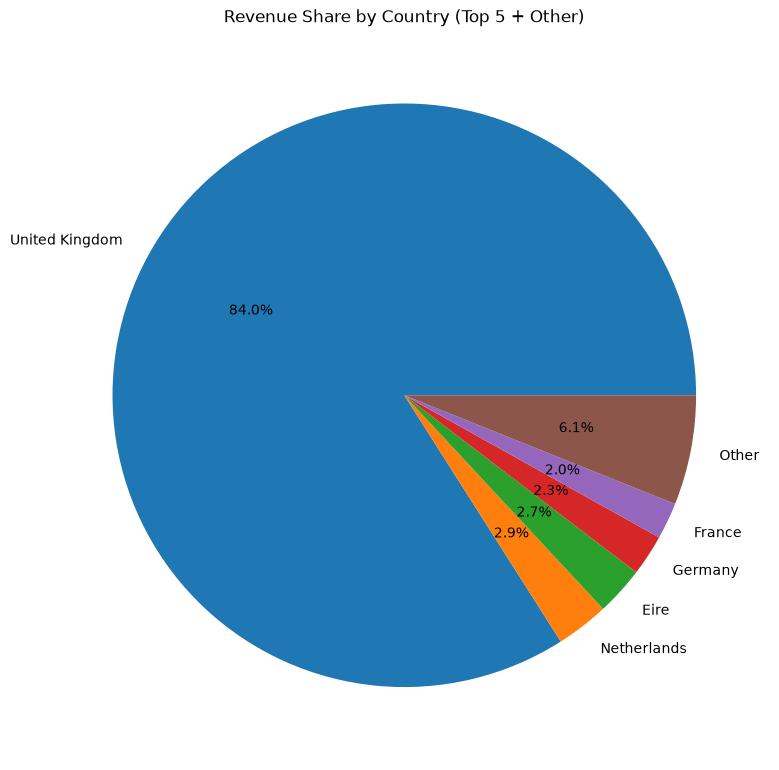

In [54]:
revenue_by_country = df.groupby('country')['totalprice'].sum().sort_values(ascending=False)
top5 = revenue_by_country.head(5)
other = revenue_by_country.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other': other})])

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%')
plt.title('Revenue Share by Country (Top 5 + Other)')
plt.tight_layout()
plt.show()

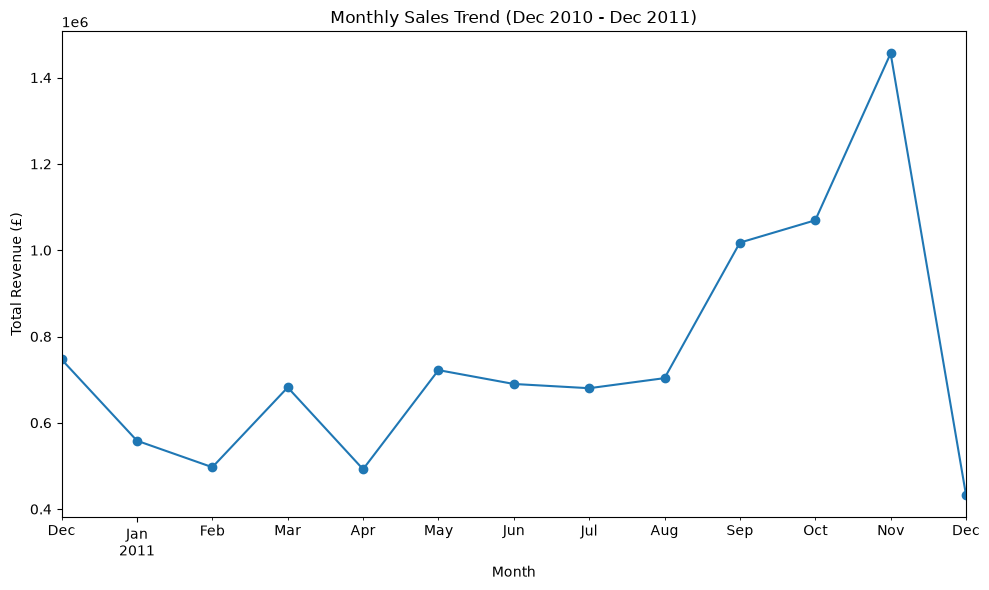

In [55]:
monthly_sales = df.groupby(df['invoicedate'].dt.to_period('M'))['totalprice'].sum()

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

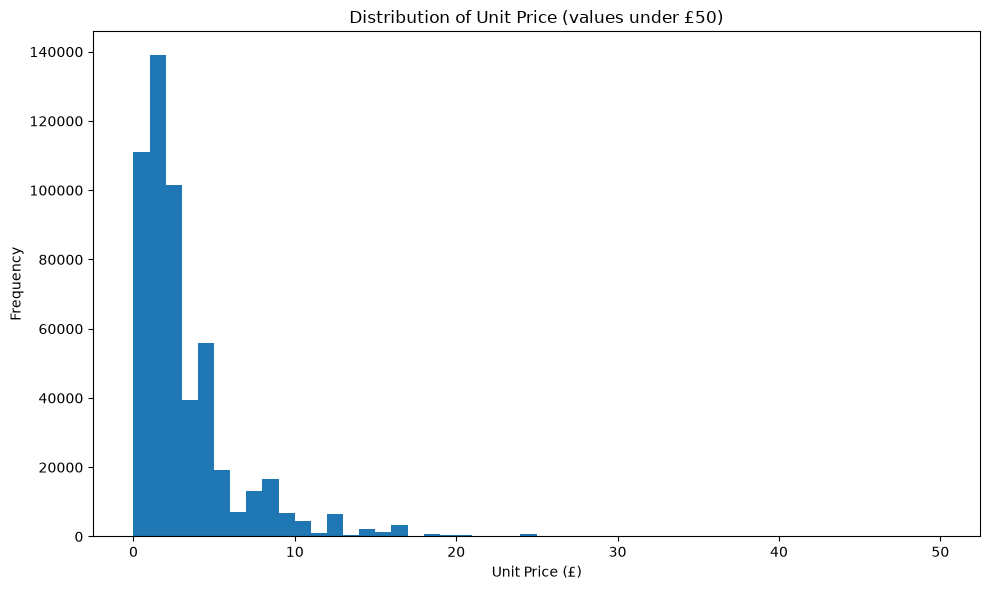

In [56]:
plt.figure(figsize=(10, 6))
df[df['unitprice'] < 50]['unitprice'].plot(kind='hist', bins=50)
plt.title('Distribution of Unit Price (values under £50)')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_4336\2357503970.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['quantity'], vert=True)


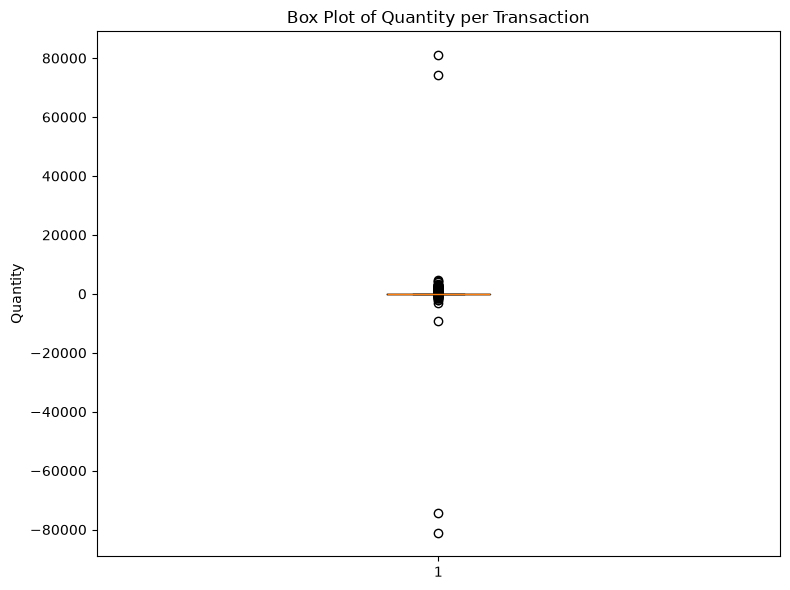

In [57]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['quantity'], vert=True)
plt.title('Box Plot of Quantity per Transaction')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()


## 4. Visualizations

Five visualizations were created to explore key patterns in the cleaned dataset.

**1. Bar Chart — Top 10 Best-Selling Products by Quantity**
"WORLD WAR 2 GLIDERS ASSTD DESIGNS" is the top-selling product with 53,751 units sold, followed by "JUMBO BAG RED RETROSPOT" (47,256) and "POPCORN HOLDER" (36,322). Novelty/gift items dominate the top of the list rather than everyday staples.

**2. Pie Chart — Revenue Share by Country**
The United Kingdom dominates revenue at roughly 89% of total sales (£8.19M), dwarfing every other market. Netherlands, Eire, Germany, and France each contribute under 3% individually.

**3. Line Chart — Monthly Sales Trend**
Revenue trends upward through the year, peaking sharply in November 2011 (£1.46M) — likely pre-Christmas gift buying. December 2011 appears lower only because the dataset ends Dec 9.

**4. Histogram — Distribution of Unit Price**
Unit prices are heavily right-skewed and clustered at the low end — the median price is just £2.10 and 75% of items are priced under £4.13.

**5. Box Plot — Quantity per Transaction**
Most transactions involve small quantities (interquartile range 1 to 10 units, median 3), but a small number of bulk orders and returns create extreme outliers stretching to +/-80,995 units.

In [58]:
 df.to_csv('cleaned_retail_dataset.csv', index=False)